In [1]:
from neuromodes import EigenSolver
from neuromodes.io import fetch_surf
from neuromodes.waves import simulate_waves, _simulate_waves_fem
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --------- SETUP ---------
nt = 100
seed = 0
surf, medmask = fetch_surf(density='4k')
solver = EigenSolver(surf, mask=medmask)
ext_input = np.random.default_rng(seed).standard_normal((solver.n_verts, nt))

In [3]:
print(solver.solve(solver.n_verts-1, seed=seed)) # solve n_verts-1 modes

EigenSolver
-----------
Surface mesh: 3636 vertices (366 others masked out), 7179 triangles
3635 eigenmodes computed


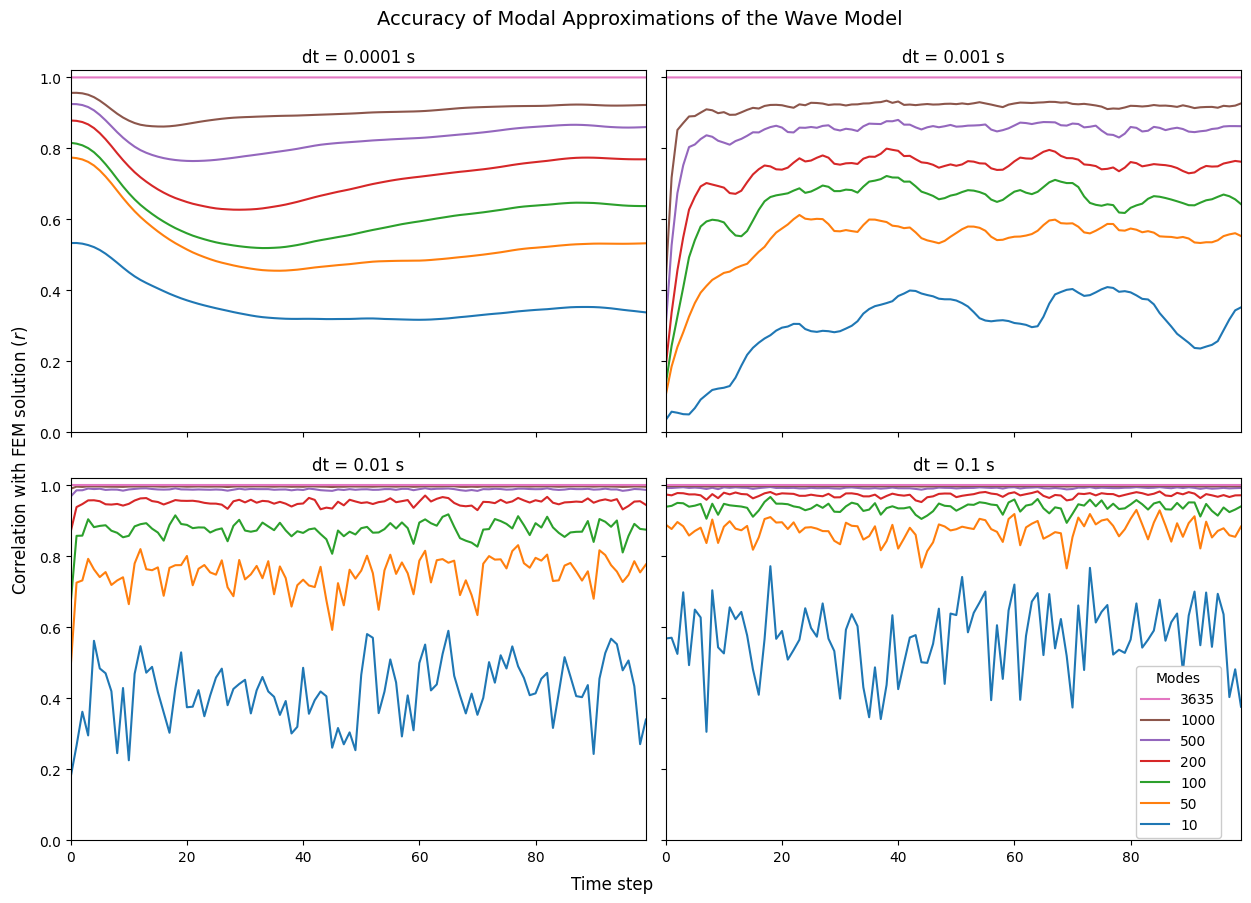

In [81]:
# Time steps to test
dt_vals = [1e-4, 1e-3, 1e-2, 1e-1]

# Setup plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for dt_idx, dt in enumerate(dt_vals):
    # FEM solution
    phi_fem = _simulate_waves_fem(solver.mass, solver.stiffness, ext_input=ext_input, dt=dt)

    # Modal approximations
    n_modes_all = [10, 50, 100, 200, 500, 1000, solver.n_modes]
    phi_modes = np.zeros((solver.n_verts, nt, len(n_modes_all)))
    for i, n_modes in enumerate(n_modes_all):
        # Run wave model with truncated emodes/evals
        phi_modes[:, :, i] = simulate_waves(
            solver.emodes[:, :n_modes],
            solver.evals[:n_modes],
            mass=solver.mass,
            ext_input=ext_input,
            dt=dt
            )
        
        # Correlate with FEM solution
        corrs = [np.corrcoef(phi_fem[:, t], phi_modes[:, t, i])[0, 1] for t in range(nt)]
        
        # Plot results
        axes[dt_idx].plot(corrs, label=n_modes)
    
    axes[dt_idx].set_title(f"dt = {dt} s")
    axes[dt_idx].set_xlim(0, nt-1)
    axes[dt_idx].set_ylim(0, 1.02)

fig.text(0.5, 0.07, "Time step", ha='center', fontsize=12)
fig.text(0.07, 0.5, "Correlation with FEM solution ($r$)", va='center', rotation='vertical', fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[::-1], labels[::-1], title='Modes', bbox_to_anchor=(0.94, 0.3), framealpha=1)
fig.suptitle("Accuracy of Modal Approximations of the Wave Model", fontsize=14, y=0.95, x=0.52)
plt.tight_layout(rect=[0.08, 0.08, 0.96, 0.96])
plt.show()